In [1]:
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For handling numerical operations (optional)

In [ ]:
                     Employee Turnover Analytics.
                         Course-end Project

In [ ]:
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For handling numerical operations (optional)

In [2]:
import pandas as pd

# Load the dataset
file_path = "HR_comma_sep.csv"
df = pd.read_csv(file_path)

# Check for missing values
missing_values = df.isnull().sum()
missing_values



,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


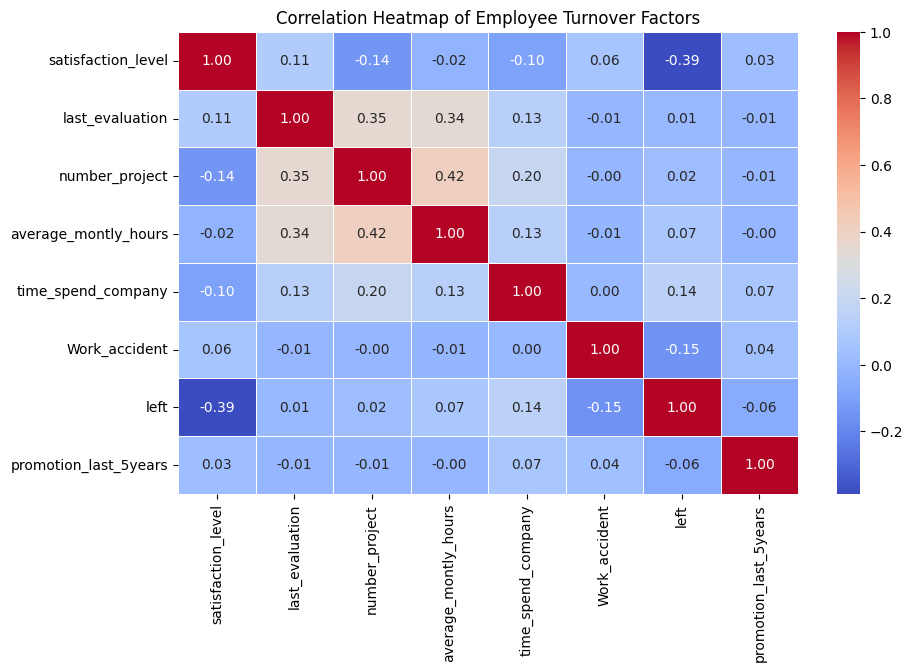

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Display basic dataset info
df_info = df.describe()

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=np.number)

# Compute correlation matrix on numeric data
correlation_matrix = numeric_df.corr()

# Plot heatmap of correlations
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Employee Turnover Factors")
plt.show()

df_info


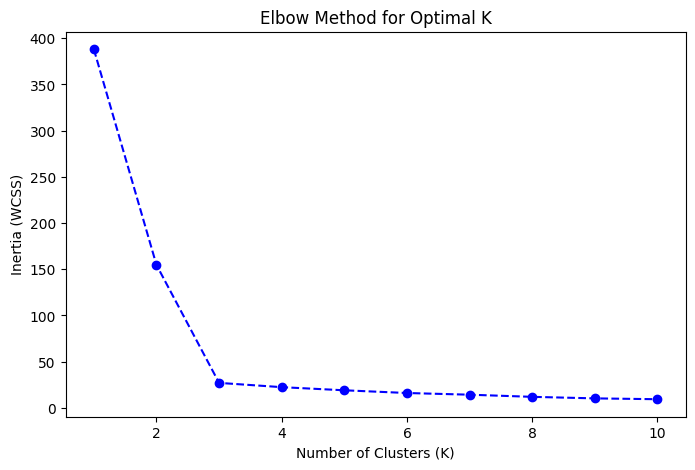

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Load the dataset
file_path = "HR_comma_sep.csv"
df = pd.read_csv(file_path)

# Filter employees who left
df_left = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]

# Determine the optimal number of clusters using the Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_left)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.show()


In [12]:
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# Load the dataset
file_path = "HR_comma_sep.csv"
df = pd.read_csv(file_path)

# Separate features and target variable
X = df.drop(columns=['left'])  # Features
y = df['left']  # Target

# Perform one-hot encoding on categorical features
X = pd.get_dummies(X, columns=['sales', 'salary']) # Assuming 'sales' and 'salary' are your categorical columns

# Check class distribution before SMOTE
class_distribution_before = y.value_counts()

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check class distribution after SMOTE
class_distribution_after = np.bincount(y_resampled)

(class_distribution_before, class_distribution_after)

(left
 0    11428
 1     3571
 Name: count, dtype: int64,
 array([11428, 11428]))

In [13]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("HR_comma_sep.csv")

# Encode categorical variables
df['salary'] = LabelEncoder().fit_transform(df['salary'])
df['sales'] = LabelEncoder().fit_transform(df['sales'])

# Define features and target
X = df.drop(columns=['left'])
y = df['left']

# Apply K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(random_state=42)

# Evaluate model using cross-validation
scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

# Print results
print("Accuracy scores:", scores)
print("Mean Accuracy:", scores.mean())


Accuracy scores: [0.98866667 0.99266667 0.99133333 0.99233333 0.993998  ]
Mean Accuracy: 0.9917995998666221


In [3]:
import pandas as pd

# Load the dataset
file_path = "HR_comma_sep.csv"
df = pd.read_csv(file_path)

# Display basic information and the first few rows
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


(None,
    satisfaction_level  last_evaluation  number_project  average_montly_hours  \
 0                0.38             0.53               2                   157   
 1                0.80             0.86               5                   262   
 2                0.11             0.88               7                   272   
 3                0.72             0.87               5                   223   
 4                0.37             0.52               2                   159   
 
    time_spend_company  Work_accident  left  promotion_last_5years  sales  \
 0                   3              0     1                      0  sales   
 1                   6              0     1                      0  sales   
 2                   4              0     1                      0  sales   
 3                   5              0     1                      0  sales   
 4                   3              0     1                      0  sales   
 
    salary  
 0     low  
 1  medium  
 2

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables
df_encoded = df.copy()
le_sales = LabelEncoder()
le_salary = LabelEncoder()
df_encoded['sales'] = le_sales.fit_transform(df_encoded['sales'])
df_encoded['salary'] = le_salary.fit_transform(df_encoded['salary'])

# Define features and target
X = df_encoded.drop(columns=['left'])
y = df_encoded['left']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize numerical features for models like Logistic Regression and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check class distribution to understand if it's imbalanced
y.value_counts(normalize=True)


left
0    0.761917
1    0.238083
Name: proportion, dtype: float64

/tmp/ipykernel_184/3135697172.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[feature], label='Original', ax=axes[row, col], color='blue', shade=True)
/tmp/ipykernel_184/3135697172.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train_scaled_df[feature], label='Scaled', ax=axes[row, col], color='red', shade=True)
/tmp/ipykernel_184/3135697172.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[feature], label='Original', ax=axes[row, col], color='blue', shade=True)
/tmp/ipykernel_184/3135697172.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This wil

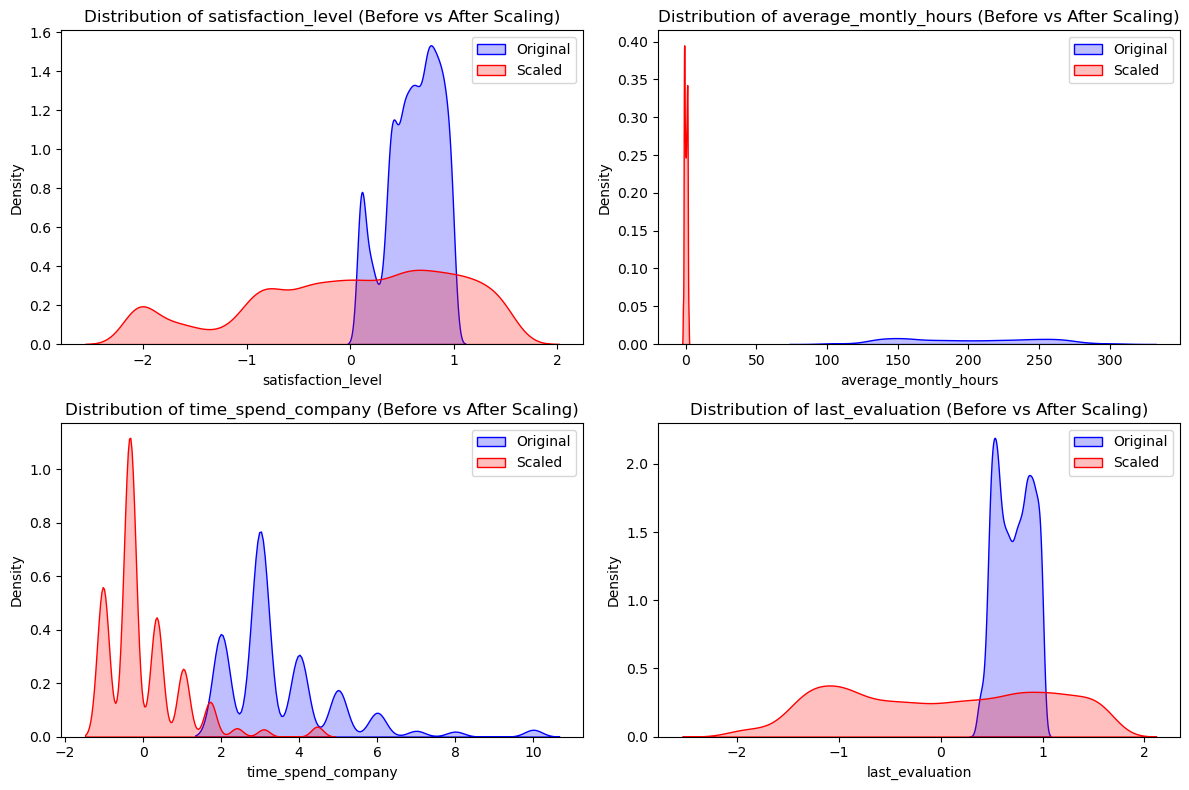

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert scaled data back to DataFrame for visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# Plot original vs scaled data distribution for key features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features_to_plot = ['satisfaction_level', 'average_montly_hours', 'time_spend_company', 'last_evaluation']

for i, feature in enumerate(features_to_plot):
    row, col = divmod(i, 2)
    sns.kdeplot(X_train[feature], label='Original', ax=axes[row, col], color='blue', shade=True)
    sns.kdeplot(X_train_scaled_df[feature], label='Scaled', ax=axes[row, col], color='red', shade=True)
    axes[row, col].set_title(f"Distribution of {feature} (Before vs After Scaling)")
    axes[row, col].legend()

plt.tight_layout()
plt.show()
